# Preprocessing

In this lab, we will be exploring how to preprocess tweets for sentiment analysis. 

In [76]:
import nltk 
from nltk.corpus import twitter_samples,stopwords
import matplotlib.pyplot as plt
import random
import re
from nltk.tokenize import TweetTokenizer
import string
from nltk.stem import PorterStemmer

## About the Twitter dataset

The sample dataset from NLTK is separated into positive and negative tweets. It contains 5000 positive tweets and 5000 negative tweets exactly. 

In [10]:
# Download the twitter dataset
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     C:\Users\lekal\AppData\Roaming\nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [66]:
# Load the positive negative tweets`
all_positive_tweet=twitter_samples.strings('positive_tweets.json')
all_negative_tweet=twitter_samples.strings('negative_tweets.json')

In [67]:
# find count of positive and negative tweet
print(f"Number of positive tweet: {len(all_positive_tweet)}\nNumber of negative tweet: {len(all_negative_tweet)} ")

# find the datatype of the tweet
print(f"Type of all positive tweet: {type(all_positive_tweet)}\nType of first negative tweet:{type(all_negative_tweet[0])} ")

Number of positive tweet: 5000
Number of negative tweet: 5000 
Type of all positive tweet: <class 'list'>
Type of first negative tweet:<class 'str'> 


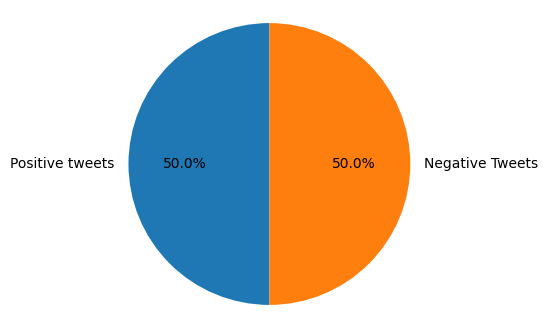

In [68]:
fig=plt.figure(figsize=(4,4))
labels='Positive tweets','Negative Tweets'
size=[len(all_positive_tweet),len(all_negative_tweet)]
plt.pie(size,labels=labels,startangle=90,autopct='%1.1f%%')
plt.axis('equal')
plt.show()

## Looking at raw texts

Before anything else, we can print a couple of tweets from the dataset to see how they look. 

In [69]:
# print positive and negative tweets

print(f"Positive tweet: {all_positive_tweet[random.randint(0,5000)]}\n\n\nNegative tweet: {all_negative_tweet[random.randint(0,5000)]}")

Positive tweet: @BergsonSandra Its getting big! :-)


Negative tweet: Clara and Yiling left me :(


For NLP, the preprocessing steps are comprised of the following tasks:

* Tokenizing the string
* Lowercasing
* Removing stop words and punctuation
* Stemming

In [70]:
# Take one tweet `
tweet=all_positive_tweet[2277]
print(tweet)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i


In [71]:
# Download stopword
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lekal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Remove hyperlinks,  Twitter marks and styles



In [72]:
print('\033[92m' + tweet)
print('\033[94m')

# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet)

# remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)

# remove hashtags
# only removing the hash # sign from the word
tweet2 = re.sub(r'#', '', tweet2)

print(tweet2)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


### Tokenize the string

To tokenize means to split the strings into individual words without blanks or tabs. In this same step, we will also convert each word in the string to lower case.


In [73]:
print()
print('\033[92m' + tweet2)
print('\033[94m')

# Create object for class TweetTokenizer
tokenizer=TweetTokenizer(preserve_case=False,strip_handles=True,reduce_len=True)

# update tweet
tweet_token=tokenizer.tokenize(tweet2)

print(f"Tokenized string: {tweet_token} ")



My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 

Tokenized string: ['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off', '…'] 


### Remove stop words and punctuations

The next step is to remove stop words and punctuation. Stop words are words that don't add significant meaning to the text. You'll see the list provided by NLTK when you run the cells below.

In [74]:
stopword_english=stopwords.words('english')
print(f'Stop word: {stopword_english} ')
print(f"Punctuation : {string.punctuation} ")

Stop word: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "sh

We can see that the stop words list above contains some words that could be important in some contexts. 
These could be words like _i, not, between, because, won, against_. You might need to customize the stop words list for some applications. For our exercise, we will use the entire list.

For the punctuation, we saw earlier that certain groupings like ':)' and '...'  should be retained when dealing with tweets because they are used to express emotions. In other contexts, like medical analysis, these should also be removed.

Time to clean up our tokenized tweet!

In [75]:
print()
print('\033[92m')
print(tweet_token)
print('\033[94m')

tweets_clean = []
for words in tweet_token:
    if (words not in stopword_english and words not in string.punctuation):
        tweets_clean.append(words)
print(f"Removed stop word and punctuation: {tweets_clean} ")



['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off', '…']

Removed stop word and punctuation: ['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…'] 


### Stemming

Stemming is the process of converting a word to its most general form, or stem. This helps in reducing the size of our vocabulary.

Consider the words: 
 * **learn**
 * **learn**ing
 * **learn**ed
 * **learn**t
 
All these words are stemmed from its common root **learn**. However, in some cases, the stemming process produces words that are not correct spellings of the root word. For example, **happi** and **sunni**. That's because it chooses the most common stem for related words. For example, we can look at the set of words that comprises the different forms of happy:

 * **happ**y
 * **happi**ness
 * **happi**er
 
We can see that the prefix **happi** is more commonly used. We cannot choose **happ** because it is the stem of unrelated words like **happen**.
 

In [78]:
print()
print('\033[92m')
print(tweets_clean)
print('\033[94m')

# Create object for class 
stemmer=PorterStemmer()

tweet_stem=[]

for words in tweets_clean:
    stem_word=stemmer.stem(words)
    tweet_stem.append(stem_word)
print(f"Stemmed word: {tweet_stem} ")




['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…']

Stemmed word: ['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…'] 
